<a href="https://colab.research.google.com/github/sushant758/MATHS-FOR-ML-/blob/main/day10.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Day 10 — Singular Value Decomposition (SVD)

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.image import imread

In [4]:
img = imread("my_image.jpg.png")

In [5]:
print(img.shape)

(800, 1200, 4)


In [6]:
# Convert to Grayscale
img_gray = np.mean(img, axis=2)

In [7]:
img_gray

array([[1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       ...,
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.],
       [1., 1., 1., ..., 1., 1., 1.]], dtype=float32)

In [8]:
print(img_gray.shape)

(800, 1200)


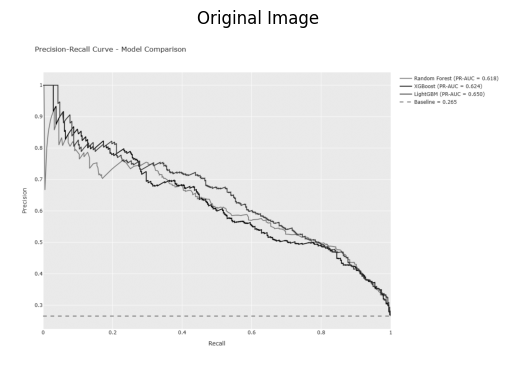

In [9]:
plt.imshow(img_gray, cmap="gray")
plt.title("Original Image")
plt.axis("off")
plt.show()

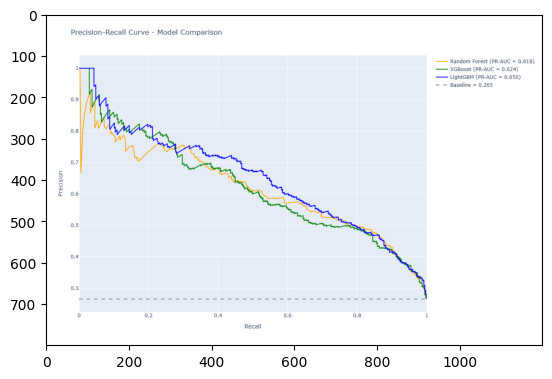

In [11]:
plt.imshow(img)
plt.show()

In [12]:
# Apply SVD
U, S, VT = np.linalg.svd(img_gray)

In [13]:
print(U.shape)
print(S.shape)
print(VT.shape)

(800, 800)
(800,)
(1200, 1200)


In [14]:
# Understand Components

print(S[:20])

[945.5053     15.341139   12.54108     9.863241    9.21874     8.362016
   8.092155    7.60876     7.139979    7.07313     6.773932    6.581328
   6.486909    6.278146    6.195522    5.958531    5.840795    5.763065
   5.7350636   5.596069 ]


In [15]:
# Choose k
k = 50

In [16]:
# Create Reduced Matrices

U_k = U[:, :k]

S_k = np.diag(S[:k])

VT_k = VT[:k, :]

In [17]:
print(U_k.shape)
print(S_k.shape)
print(VT_k.shape)

(800, 50)
(50, 50)
(50, 1200)


In [18]:
# Reconstruct Image

img_reconstructed = U_k @ S_k @ VT_k

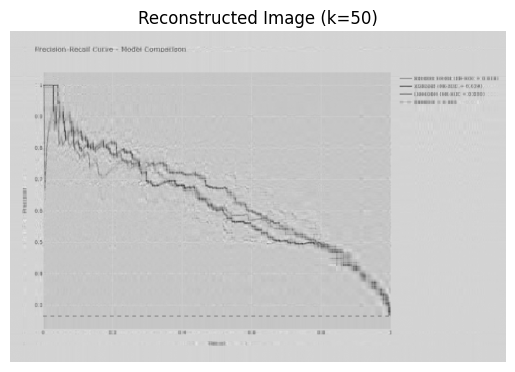

In [19]:
# Display Reconstructed Image

plt.imshow(img_reconstructed, cmap="gray")
plt.title(f"Reconstructed Image (k={k})")
plt.axis("off")
plt.show()

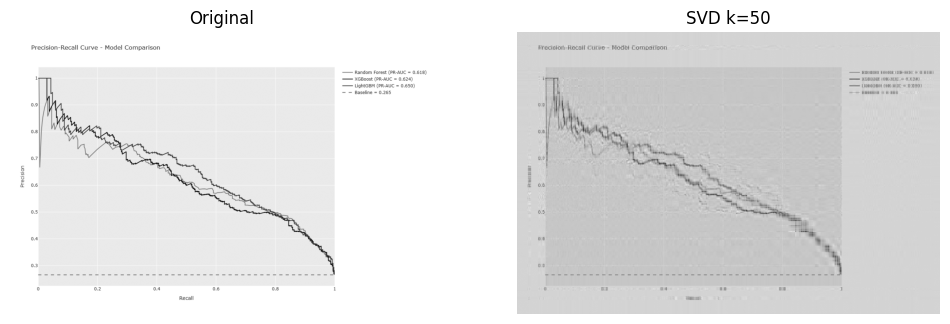

In [20]:
# Compare Original vs Reconstructed

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
plt.imshow(img_gray, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(img_reconstructed, cmap="gray")
plt.title(f"SVD k={k}")
plt.axis("off")

plt.show()

In [21]:
# Compression Ratio

original_storage = img_gray.size

In [22]:
compressed_storage = (
    U_k.size +
    S_k.size +
    VT_k.size
)

In [23]:
print("Original:", original_storage)

print("Compressed:", compressed_storage)

print(
    "Compression Ratio:",
    compressed_storage / original_storage
)

Original: 960000
Compressed: 102500
Compression Ratio: 0.10677083333333333


# ML Applications
#   PCA
#   Recommendation Systems
 #  Image Compression
  # Latent Semantic Analysis (NLP)

# Quality ↑ as k ↑
# Compression ↓ as k ↑